## LLM exploration trajectory

3D trajectory: X = iteration, Y = `coupon_to_bath_wait_time`, Z = target property. Color defaults to fit
quality (`Good Fit`), same green/orange/red convention as `EVALUATE/fit_evaluation_log.html` -- pass
`color_col="<any numeric column>"` to color by a parameter instead (continuous colorbar, e.g.
`color_col="mixing_temp"` or even `color_col=z_col` for an extra depth cue).

Data source: `tests/csv_tests/test_reps.csv` -- a full pipeline reprocess (regenerated 2026-07-13) covering
**34 conditions**, not just the 20 in `data/results/results_reps.csv`. The 14 "missing" ones (17-13deg-*,
10-25degMix-*, and the earliest 17-5deg-4s/7s/9s runs from June 1-9) predate `run_loop.py`'s active-learning
loop -- manual/scripted sweeps, not LLM decisions -- but they're real measured data and 13 of the 14 have
usable values. That file's `date` column is just the regen batch timestamp, so real experiment dates are
recovered from the raw specimen filenames (`Specimen_N_MMDDYYYY_HHMMSS.csv`) in `data/raw/<condition>/`.

`REAL_CAMPAIGN_ONLY` restricts to the actual LLM active-learning campaign only (`nips_bath_wait_time >=
MIN_NIPS_WAIT`, i.e. after run_loop.py existed) if you want to exclude the pre-automation data -- off by
default here to show the full lifetime.

`per_rep=True` plots each of the 3 reps individually -- use this for a per-specimen property like Strain
at 50 bar. `per_rep=False` plots one point per condition -- use this for CV, which is a condition-level
stat (identical across its 3 reps), so per-rep dots would just overlap.

In [1]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH = Path("..") / "data" / "results" / "results_agg_llm.csv"
REPS_FULL_PATH = Path("..") / "tests" / "csv_tests" / "test_reps.csv"
RAW_ROOT = Path("..") / "data" / "raw"

# conditions to drop from the trajectory entirely -- not representative of a real
# active-learning step under the correct objective
EXCLUDE_CONDITIONS = {
    "10-25degMix-25deg-0s-NoN2-1800s",  # wrong prompt: told the LLM to MAXIMIZE Strain at 50 bar
}

df = pd.read_csv(CSV_PATH)
df["_dt"] = pd.to_datetime(df["date"].str.replace("\n", " "))
df = df.sort_values("_dt").reset_index(drop=True)
df["iteration"] = range(1, len(df) + 1)

SPECIMEN_RE = re.compile(r"(\d{8})_(\d{6})")

def true_condition_date(cond):
    """Earliest specimen timestamp for a condition, read from its raw folder
    (test_reps.csv's own date column is just a regen batch timestamp)."""
    d = RAW_ROOT / cond
    if not d.is_dir():
        return pd.NaT
    stamps = []
    for f in d.glob("Specimen_*.csv"):
        m = SPECIMEN_RE.search(f.name)
        if m:
            stamps.append(pd.to_datetime(m.group(1) + m.group(2), format="%m%d%Y%H%M%S"))
    return min(stamps) if stamps else pd.NaT

reps_df = pd.read_csv(REPS_FULL_PATH)
reps_df["condition"] = reps_df["name"].str.split(r"\s*\|\s*rep").str[0]
reps_df = reps_df[~reps_df["condition"].isin(EXCLUDE_CONDITIONS)].reset_index(drop=True)
reps_df["_dt"] = reps_df["condition"].apply(true_condition_date)
reps_df = reps_df.sort_values("_dt").reset_index(drop=True)
print(f"{len(reps_df)} rep rows loaded across {reps_df['condition'].nunique()} conditions "
      f"({reps_df['_dt'].min().date()} to {reps_df['_dt'].max().date()}), "
      f"{len(EXCLUDE_CONDITIONS)} condition(s) excluded")

99 rep rows loaded across 33 conditions (2026-05-28 to 2026-06-20), 1 condition(s) excluded


In [2]:
# reference: numeric columns available for X / Y
df.select_dtypes("number").columns.tolist()

['mixing_temp',
 'bath_temp',
 'weight_percent',
 'volume',
 'pullcast_speed',
 'coupon_to_bath_wait_time',
 'nips_bath_wait_time',
 'Thickness Mean',
 'Thickness SD',
 'Elastic Modulus Mean',
 'Elastic Modulus SD',
 'Yield Strength Mean',
 'Yield Strength SD',
 'Changepoint Mean',
 'Changepoint SD',
 'Slope Plateau Mean',
 'Slope Plateau SD',
 'Slope Densification Mean',
 'Slope Densification SD',
 'Creep Strain Mean',
 'Creep Strain SD',
 'Strain at 50 bar Mean',
 'Strain at 50 bar SD',
 'Strain at 80 bar Mean',
 'Strain at 80 bar SD',
 'Strain at 150 bar Mean',
 'Strain at 150 bar SD',
 'Strain at 500 bar Mean',
 'Strain at 500 bar SD',
 'CV Mean',
 'polymer_wt',
 'additive_wt',
 'Air Temp Mean',
 'Humidity Mean',
 'iteration']

In [3]:
MIN_NIPS_WAIT = 1000  # set REAL_CAMPAIGN_ONLY=True in a call to restrict to the post-run_loop LLM campaign

order = reps_df.drop_duplicates("condition").sort_values("_dt")["condition"].tolist()
condition_iteration = {c: i + 1 for i, c in enumerate(order)}
reps_df["iteration"] = reps_df["condition"].map(condition_iteration)

In [91]:
import numpy as np
from matplotlib.patches import Patch
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 -- registers the '3d' projection

# same convention as EVALUATE/fit_evaluation_log.html
PASS_COLOR  = "#2e7d32"  # all reps Good Fit
MIXED_COLOR = "#e65100"  # some reps Good Fit
FAIL_COLOR  = "#b71c1c"  # no reps Good Fit

MAROON_BLUE = LinearSegmentedColormap.from_list("maroon_blue", ["maroon", "red", "red", "blue", "cyan"])

def _tight_limits(lo, hi, pad_frac=0.04):
    """Zoom an axis tight to [lo, hi]: floor sits exactly at the real minimum (no empty
    buffer below the lowest point), a little padding only on the top."""
    pad = (hi - lo) * pad_frac or abs(hi) * pad_frac or 1
    return lo, hi + pad

def plot_3d_trajectory(reps_df, y_col, z_col, x_col="iteration", color_col=None, per_rep=True,
                        real_campaign_only=False, figsize=(16, 11), x_stretch=2.0, y_stretch=2.0):
    """3D trajectory: x=iteration, y=y_col, z=z_col.
    color_col=None (default): color = fit quality (Good Fit), green/orange/red.
    color_col="<any numeric column>": color that column's value on a maroon-to-blue scale
    instead (e.g. mixing_temp, bath_temp, or z_col itself as an extra depth cue) -- adds a colorbar.
    per_rep=True: one dot per rep (per-specimen properties, e.g. Strain at 50 bar).
    per_rep=False: one dot per condition (condition-level stats like CV, which repeat per rep
    so per-rep dots would just overlap).
    x_stretch: how much wider the iteration axis is drawn relative to y/z (box_aspect ratio) --
    bump this up if points are still bunched together.
    y/z axis floors sit exactly at the real min (no dead space below the lowest point)."""
    d = reps_df.copy()
    if real_campaign_only:
        d = d[d["nips_bath_wait_time"] >= MIN_NIPS_WAIT]
    d = d.dropna(subset=[z_col])
    if d.empty:
        raise ValueError(f"no reps have a usable {z_col!r} value")

    legend_items = None
    colorbar_label = None
    if color_col is not None:
        if not per_rep:
            d = d.drop_duplicates("condition")
        colors = d[color_col].astype(float).values
        colorbar_label = color_col
    elif per_rep:
        colors = np.where(d["Good Fit"].astype(bool), PASS_COLOR, FAIL_COLOR)
        legend_items = [Patch(color=PASS_COLOR, label="Good Fit"),
                         Patch(color=FAIL_COLOR, label="Bad Fit")]
    else:
        status = d.groupby("condition")["Good Fit"].agg(lambda s: "pass" if s.all()
                                                          else ("fail" if not s.any() else "mixed"))
        d = d.drop_duplicates("condition")
        status_color = {"pass": PASS_COLOR, "mixed": MIXED_COLOR, "fail": FAIL_COLOR}
        colors = d["condition"].map(status).map(status_color).values
        legend_items = [Patch(color=PASS_COLOR, label="all reps Good Fit"),
                         Patch(color=MIXED_COLOR, label="some reps Good Fit"),
                         Patch(color=FAIL_COLOR, label="no reps Good Fit")]

    means = d.groupby("condition").agg({x_col: "first", y_col: "first", z_col: "mean"}) \
        .sort_values(x_col)
    print(f"{d['condition'].nunique()} condition(s), {len(d)} point(s) plotted for {z_col!r}")

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")
    ax.set_box_aspect((x_stretch, y_stretch, 1.5))  # stretch the iteration axis so points spread out
    ax.plot(means[x_col], means[y_col], means[z_col], "-", color="gray", alpha=0.4, zorder=1)
    # depthshade=True (default) -- mplot3d fades far-away markers to fake depth; kept on purpose.
    sc = ax.scatter(d[x_col], d[y_col], d[z_col], c=colors if colorbar_label else None,
                     color=None if colorbar_label else colors,
                     cmap=MAROON_BLUE if colorbar_label else None,
                     edgecolor="k", s=90, zorder=2, depthshade=True)

    if colorbar_label:
        fig.colorbar(sc, ax=ax, label=colorbar_label, shrink=0.6, pad=0.12)
    else:
        ax.legend(handles=legend_items, loc="upper left", fontsize=9)

    # zoom y/z tight to the real data range instead of matplotlib padding down to 0
    y_lo, y_hi = _tight_limits(d[y_col].min()+90, d[y_col].max()-150)
    ax.set_ylim(y_lo, y_hi)

    z_lo, z_hi = _tight_limits(d[z_col].min(), d[z_col].max())
    ax.set_zlim(z_lo, z_hi)

    ax.set_xlabel(x_col, labelpad=15)
    ax.set_ylabel(y_col, labelpad=15)
    ax.set_zlabel(z_col, labelpad=10)
    ax.set_title(f"exploration trajectory {'(per-rep)' if per_rep else '(per-condition)'} -- {z_col}")
    plt.show()
    cols = ["condition", x_col, y_col, z_col]
    if per_rep and color_col is None:
        cols.append("Good Fit")
    if color_col is not None and color_col not in cols:
        cols.append(color_col)
    return d[cols]

24 condition(s), 71 point(s) plotted for 'Strain at 50 bar'


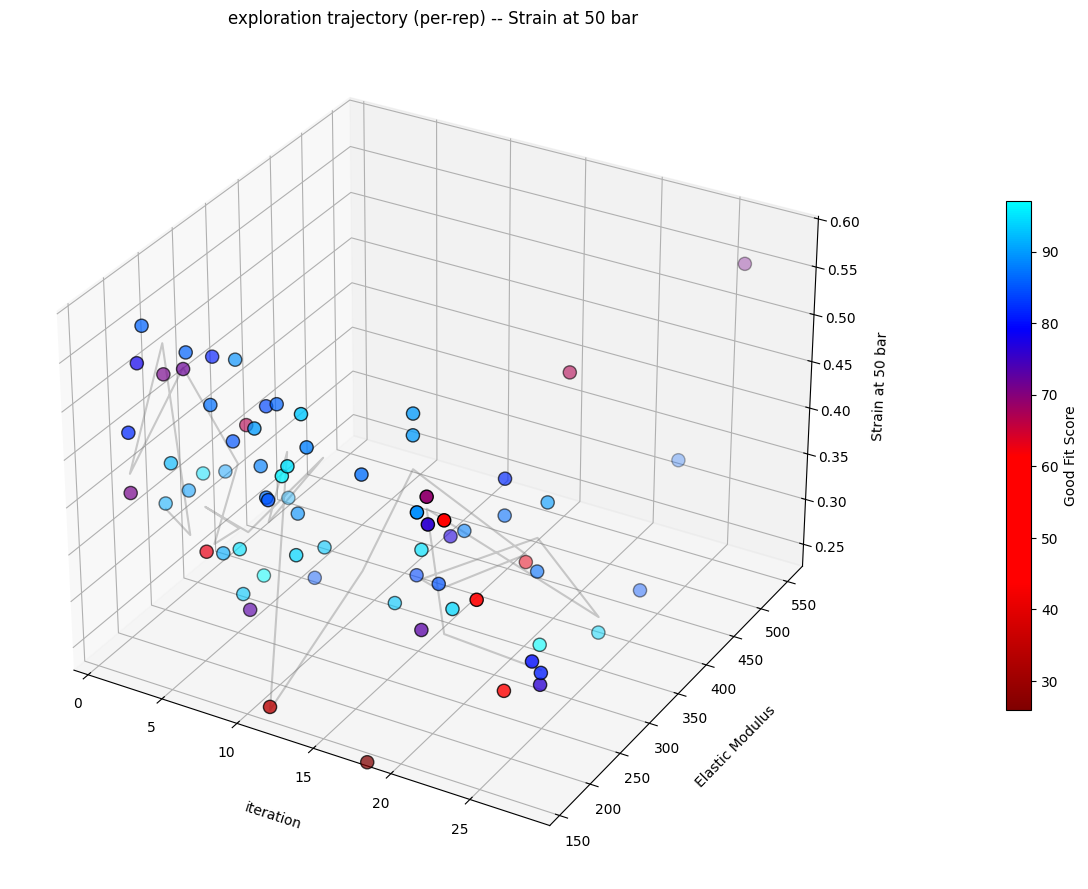

,condition,iteration,Elastic Modulus,Strain at 50 bar,Good Fit Score
0,17-13deg-120s-NoN2-1800s,1,234.693530,0.355951,91.0
1,17-13deg-120s-NoN2-1800s,1,325.264502,0.338412,90.0
2,17-13deg-120s-NoN2-1800s,1,291.497956,0.355617,95.0
3,17-13deg-120s-NoN2-1900s,2,247.883351,0.367114,90.0
5,17-13deg-120s-NoN2-1900s,2,400.265320,0.270607,91.0
...,...,...,...,...,...
79,17-5deg-450s-N2-1800s,27,92.969340,0.469164,47.0
80,17-5deg-450s-N2-1800s,27,136.043848,0.349565,58.0
81,17-5deg-310s-N2-1800s,28,168.656181,0.352727,81.0
82,17-5deg-310s-N2-1800s,28,154.202279,0.373661,80.0


In [92]:
# edit and rerun -- per-specimen property, so per_rep=True
plot_3d_trajectory(reps_df, y_col="Elastic Modulus", z_col="Strain at 50 bar", color_col="Good Fit Score", per_rep=True)

24 condition(s), 72 point(s) plotted for 'CV'


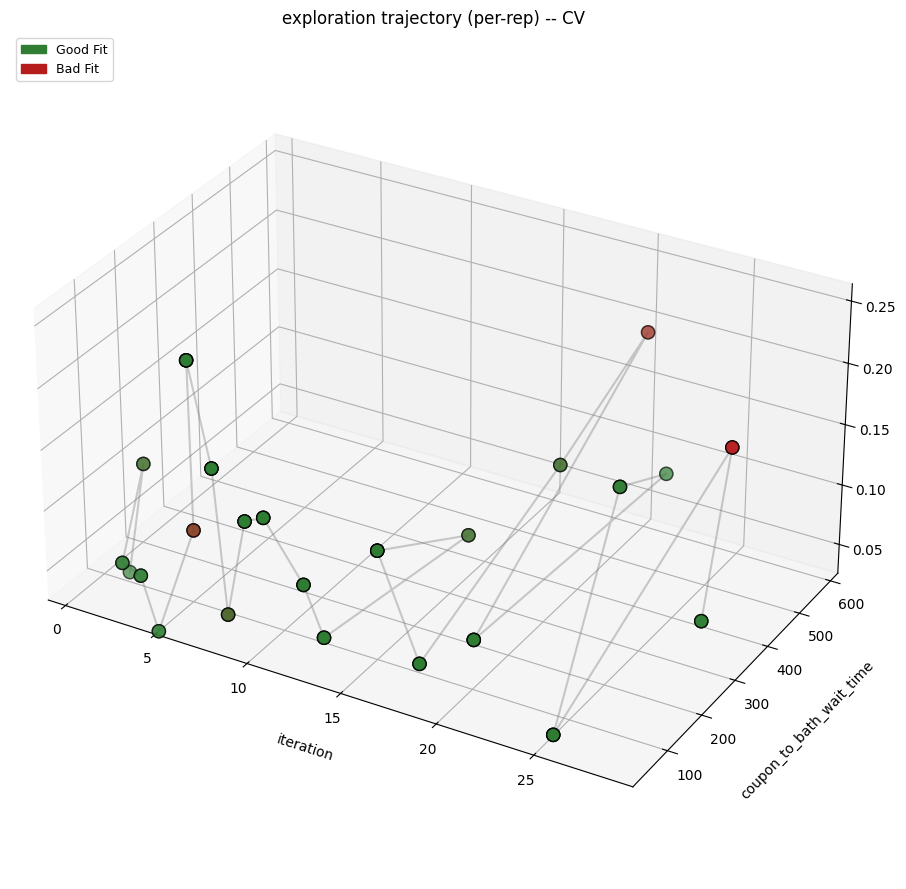

,condition,iteration,coupon_to_bath_wait_time,CV,Good Fit
0,17-13deg-120s-NoN2-1800s,1,120,0.026148,True
1,17-13deg-120s-NoN2-1800s,1,120,0.026148,True
2,17-13deg-120s-NoN2-1800s,1,120,0.026148,True
3,17-13deg-120s-NoN2-1900s,2,120,0.121720,True
4,17-13deg-120s-NoN2-1900s,2,120,0.121720,False
...,...,...,...,...,...
79,17-5deg-450s-N2-1800s,27,450,0.162414,False
80,17-5deg-450s-N2-1800s,27,450,0.162414,False
81,17-5deg-310s-N2-1800s,28,310,0.062147,True
82,17-5deg-310s-N2-1800s,28,310,0.062147,True


In [6]:
# CV is a condition-level stat (same value for all 3 reps), so per_rep=False
plot_3d_trajectory(reps_df, y_col="coupon_to_bath_wait_time", z_col="CV", per_rep=True)